# 01 Dataset Audit v0.1

**Notebook version:** v0.1  
**Category:** inspection  
**Purpose:** Audit imported training and validation corpuses, verify authoritative manifests, inspect NPZ shard schema, and surface leakage/geometry risks before training.  
**Inputs:** `./training-data`, `./validation-data`  
**Expected outputs:** In-notebook diagnostics/tables/plots only (no canonical run artifacts).  
**Artifact write mode:** no canonical artifacts  
**Decision supported:** `READY_FOR_TRAINING` vs `PATCH_REQUIRED`


In [1]:
# Repo Setup
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    for parent in repo_root.parents:
        if (parent / 'src').exists() and (parent / 'training-data').exists() and (parent / 'validation-data').exists():
            repo_root = parent
            break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'repo_root={repo_root}')


repo_root=/home/mitch/development/raccoon-ball/03_rb-training-v2.0


In [2]:
# Audit Config
TRAINING_ROOT = repo_root / 'training-data'
VALIDATION_ROOT = repo_root / 'validation-data'
PADDING_MODE = 'disabled'
CHECK_SHARD_HASH_OVERLAP = True

print('TRAINING_ROOT', TRAINING_ROOT)
print('VALIDATION_ROOT', VALIDATION_ROOT)
print('PADDING_MODE', PADDING_MODE)


TRAINING_ROOT /home/mitch/development/raccoon-ball/03_rb-training-v2.0/training-data
VALIDATION_ROOT /home/mitch/development/raccoon-ball/03_rb-training-v2.0/validation-data
PADDING_MODE disabled


In [3]:
# Metadata Load
from src.data import (
    load_root_metadata,
    validate_root_schema,
    determine_target_hw,
    summarize_metadata,
)

train_metadata, train_infos = load_root_metadata(TRAINING_ROOT, source_root='training', repo_root=repo_root)
val_metadata, val_infos = load_root_metadata(VALIDATION_ROOT, source_root='validation', repo_root=repo_root)

train_schema = validate_root_schema(train_metadata, root_name='training')
val_schema = validate_root_schema(val_metadata, root_name='validation')
combined_schema = pd.concat([train_schema, val_schema], ignore_index=True)
target_hw = determine_target_hw(combined_schema, padding_mode=PADDING_MODE)

print('training_rows', len(train_metadata))
print('validation_rows', len(val_metadata))
print('target_hw', target_hw)


training_rows 200000
validation_rows 50000
target_hw (300, 300)


In [4]:
# Summary Tables
train_summary = summarize_metadata(train_metadata)
val_summary = summarize_metadata(val_metadata)

display(Markdown('## Training Summary'))
display(pd.DataFrame([train_summary]))

display(Markdown('## Validation Summary'))
display(pd.DataFrame([val_summary]))

display(Markdown('## Training Shard Schema'))
display(train_schema[['npz_filename', 'n_rows_from_x', 'n_rows_manifest', 'x_shape', 'x_dtype', 'keys']])

display(Markdown('## Validation Shard Schema'))
display(val_schema[['npz_filename', 'n_rows_from_x', 'n_rows_manifest', 'x_shape', 'x_dtype', 'keys']])


## Training Summary

,source_root,num_corpuses,num_samples,num_unique_shards,dataset_ids,distance_m
0,training,1,200000,25,[def90_synth_v023-test-shuffled],"{'min': 1.5252020359039307, 'max': 7.497079849..."


## Validation Summary

,source_root,num_corpuses,num_samples,num_unique_shards,dataset_ids,distance_m
0,validation,1,50000,7,[def90_synth_v023-validation-shuffled],"{'min': 1.5247479677200317, 'max': 7.447205066..."


## Training Shard Schema

,npz_filename,n_rows_from_x,n_rows_manifest,x_shape,x_dtype,keys
0,def90_synth_v023-test-shuffled_shard_00000.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
1,def90_synth_v023-test-shuffled_shard_00001.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
2,def90_synth_v023-test-shuffled_shard_00002.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
3,def90_synth_v023-test-shuffled_shard_00003.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
4,def90_synth_v023-test-shuffled_shard_00004.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
5,def90_synth_v023-test-shuffled_shard_00005.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
6,def90_synth_v023-test-shuffled_shard_00006.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
7,def90_synth_v023-test-shuffled_shard_00007.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
8,def90_synth_v023-test-shuffled_shard_00008.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
9,def90_synth_v023-test-shuffled_shard_00009.npz,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."


## Validation Shard Schema

,npz_filename,n_rows_from_x,n_rows_manifest,x_shape,x_dtype,keys
0,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
1,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
2,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
3,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
4,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
5,def90_synth_v023-validation-shuffled_shard_000...,8192,8192,"(8192, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."
6,def90_synth_v023-validation-shuffled_shard_000...,848,848,"(848, 1, 300, 300)",float32,"[bbox_features, bbox_features_schema, detect_b..."


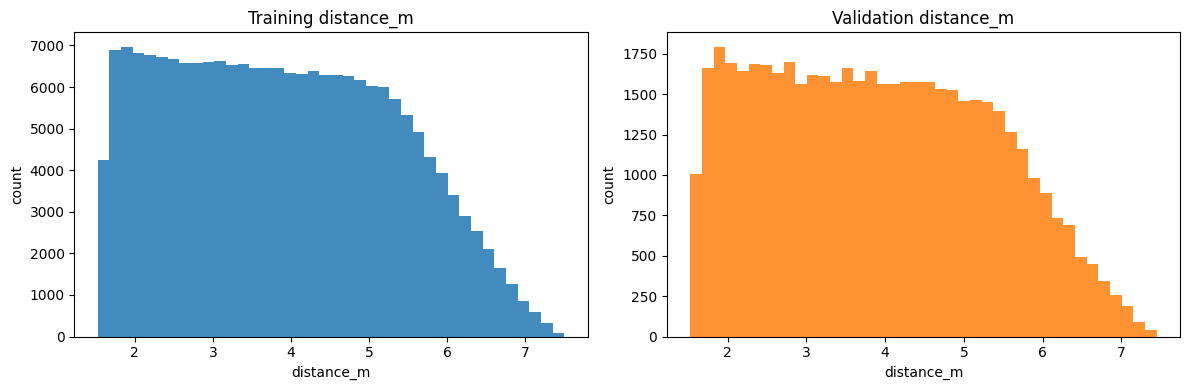

In [5]:
# Distance Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_metadata['distance_m'], bins=40, color='#1f77b4', alpha=0.85)
axes[0].set_title('Training distance_m')
axes[0].set_xlabel('distance_m')
axes[0].set_ylabel('count')

axes[1].hist(val_metadata['distance_m'], bins=40, color='#ff7f0e', alpha=0.85)
axes[1].set_title('Validation distance_m')
axes[1].set_xlabel('distance_m')
axes[1].set_ylabel('count')

fig.tight_layout()
plt.show()


TypeError: Invalid shape (1, 300, 300) for image data

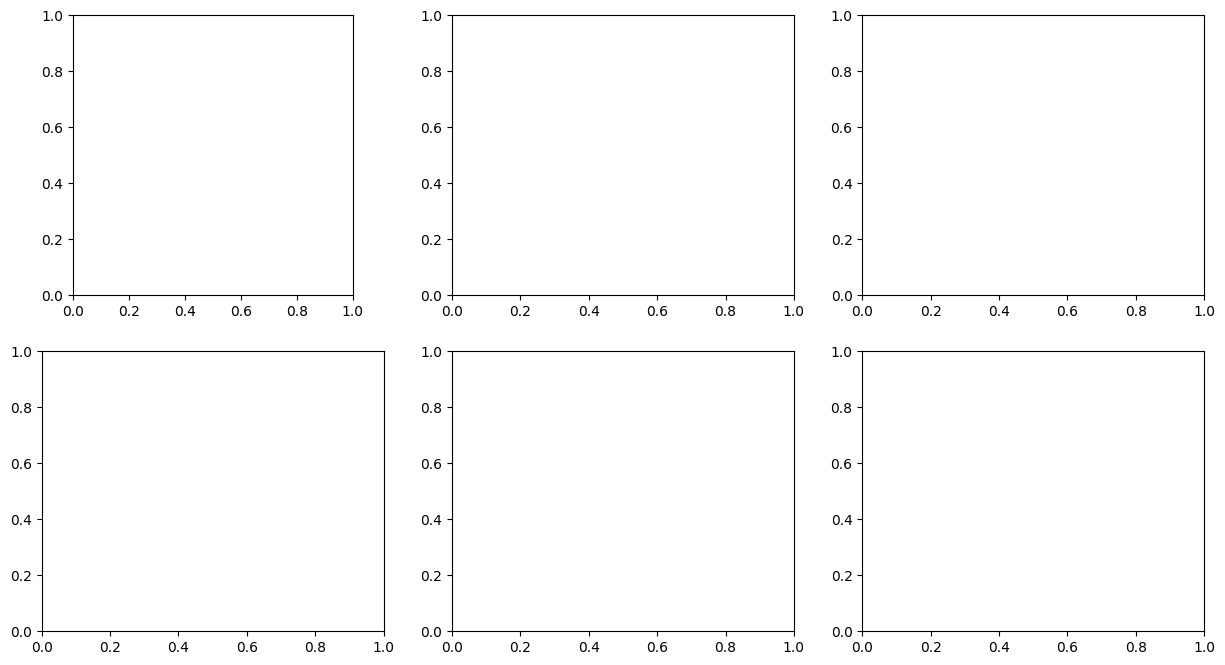

In [6]:
# Sample Preview
from src.data import read_image_preview

preview_rows = pd.concat([
    train_metadata.sort_values('npz_row_index').groupby('npz_path', as_index=False).head(1).head(3),
    val_metadata.sort_values('npz_row_index').groupby('npz_path', as_index=False).head(1).head(3),
], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.ravel(), preview_rows.iterrows()):
    image = read_image_preview(Path(row['npz_path']), int(row['npz_row_index']))
    ax.imshow(image, cmap='gray')
    ax.set_title(f"{row['source_root']}\n{row['dataset_id']}\nd={row['distance_m']:.3f}m")
    ax.axis('off')
fig.tight_layout()
plt.show()


In [ ]:
# Overlap Check
from src.data import detect_overlap_warnings

overlap_warnings, overlap_details = detect_overlap_warnings(
    train_metadata,
    val_metadata,
    check_shard_hashes=CHECK_SHARD_HASH_OVERLAP,
)

if overlap_warnings:
    display(Markdown('## Overlap Warnings'))
    for warning in overlap_warnings:
        display(Markdown(f'- {warning}'))
    display(Markdown('### Overlap Details'))
    display(overlap_details)
    FINAL_VERDICT = 'PATCH_REQUIRED'
else:
    print('No overlap warnings detected.')
    FINAL_VERDICT = 'READY_FOR_TRAINING'

print('FINAL_VERDICT', FINAL_VERDICT)


## Overlap Warnings

- Training and validation contain overlapping sample_id values.

### Overlap Details

{'overlapping_sample_id_count': 10,
 'overlapping_sample_id_examples': ['defender90_f000000_z01.500_j000',
  'defender90_f000001_z01.500_j001',
  'defender90_f000002_z01.500_j002',
  'defender90_f000003_z01.500_j003',
  'defender90_f000004_z01.500_j004',
  'defender90_f000005_z01.500_j005',
  'defender90_f000006_z01.500_j006',
  'defender90_f000007_z01.500_j007',
  'defender90_f000008_z01.500_j008',
  'defender90_f000009_z01.500_j009']}

FINAL_VERDICT PATCH_REQUIRED


## Final Verdict
`INSPECTION_COMPLETE`  
`READY_FOR_TRAINING` when schema checks pass and overlap warnings are absent.
